# <img style="float: left; padding-right: 20px; width: 200px" src="https://github.com/ymotomy/ymotomy.github.io/blob/main/imagenes/UC.png?raw=true">  IMT2118 - Ciencia de Datos Geoespaciales
**Pontificia Universidad Católica de Chile**<br>
**Semestre 2025-1**<br>
**Estudiantes:** Christian Camilo | Tomás Romero <br>
---

<hr>
<h1 style="text-align:center;"> Recomendador de Localizaciones para Observatorios en Chile usando Imágenes Satelitales y Datos Raster/Vectoriales

Chile se ha consolidado como uno de los destinos más privilegiados del mundo para la observación astronómica, gracias a sus cielos despejados, baja humedad atmosférica y reducida contaminación lumínica en vastas zonas del norte del país. Sin embargo, con el crecimiento urbano, el cambio climático y el avance de la infraestructura, resulta cada vez más necesario identificar nuevos sitios potenciales que maximicen las condiciones óptimas para la instalación de observatorios astronómicos.

Este proyecto propone el desarrollo de un sistema de recomendación basado en análisis multicriterio espacial para predecir zonas favorables para la construcción de observatorios en Chile. Para ello, se utilizarán imágenes satelitales y datos geoespaciales provenientes de diversas fuentes, tales como sensores MODIS, Sentinel-5P, Landsat y DMSP-OLS, combinando información sobre contaminación lumínica, cobertura nubosa, altitud, calidad del aire, uso de suelo y proximidad a centros urbanos.

A través del uso de herramientas como Google Earth Engine y Python, se desarrollará un flujo automatizado de procesamiento y análisis que permita integrar tanto datos raster como vectoriales. El resultado será una visualización dinámica e interactiva de los sitios más idóneos, que considere tanto criterios astronómicos como restricciones territoriales.

Este estudio busca no solo aplicar técnicas avanzadas de ciencia de datos geoespaciales, sino también contribuir a la planificación estratégica de infraestructura astronómica en Chile, promoviendo el uso sustentable del territorio en armonía con el desarrollo científico.
<hr>

In [1]:
#Primero importamos algunas librerias
import os
from glob import glob
import geemap,ee
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon
from shapely.geometry import Polygon, Point

from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import cdist

from libpysal.weights import Queen
from esda.moran import Moran
import matplotlib.pyplot as plt
from esda.moran import Moran_Local

from sklearn.cluster import KMeans

#Ignormaos los warnings
import warnings
warnings.filterwarnings("ignore")

#Sin ilmite de columnas
pd.set_option('display.max_columns', None)

In [2]:
ee.Authenticate()
# ee.Initialize(project='ee-ccamz2')
ee.Initialize(project='ee-tomasromero')

In [3]:
# Seleccionamos rango de fechas
startDate= '2024-01-01'
endDate = '2025-01-01'

## Observatorios

In [4]:
obs = gpd.read_file("Datos/observatorios/observatorios.shp").to_crs(epsg=4326)

#nos quedatos con los tipo radio, opticos, infrarrojo y los categorizamos
obs = obs[obs['Tipo'].isin(['Radio', 'Óptico', 'Infrarrojo', 'Óptico/Infrarrojo'])].reset_index(drop=True)
obs['Radio'] = obs['Tipo'].str.contains('Radio')
obs['Optico'] = obs['Tipo'].str.contains('Óptico')
obs['Infrarrojo'] = obs['Tipo'].str.contains('Infrarrojo')
obs.drop(columns=['Tipo', 'Nombre', 'Estado'], inplace=True)

print(obs.shape)
obs.head()


(71, 8)


,Altitud (m,Ubicación,Año de In,Área Lent,geometry,Radio,Optico,Infrarrojo
0,5000,"Llano de Chajnantor, Antofagasta",2003,41001.06121734071,POINT (-67.7546 -23.0221),True,False,False
1,5100,"Llano de Chajnantor, Antofagasta",2003,113.09733552923257,POINT (-67.7533 -23.0056),True,False,False
2,5190,"Cerro Toco, Antofagasta",2007,28.274333882308134,POINT (-67.7875 -22.9583),True,False,False
3,2635,"Cerro Paranal, Antofagasta",1991,211.23836840423655,POINT (-70.4042 -24.6272),False,True,True
4,3046,"Cerro Armazones, Antofagasta",2014,1194.690595328151,POINT (-70.19 -24.5895),False,True,True


In [5]:
m = gpd.read_file("Datos/ne_110m_land/ne_110m_land.shp").to_crs(epsg=4326)

(np.float64(-198.0),
 np.float64(198.00000000000014),
 np.float64(-98.68225650000004),
 np.float64(92.32738650000003))

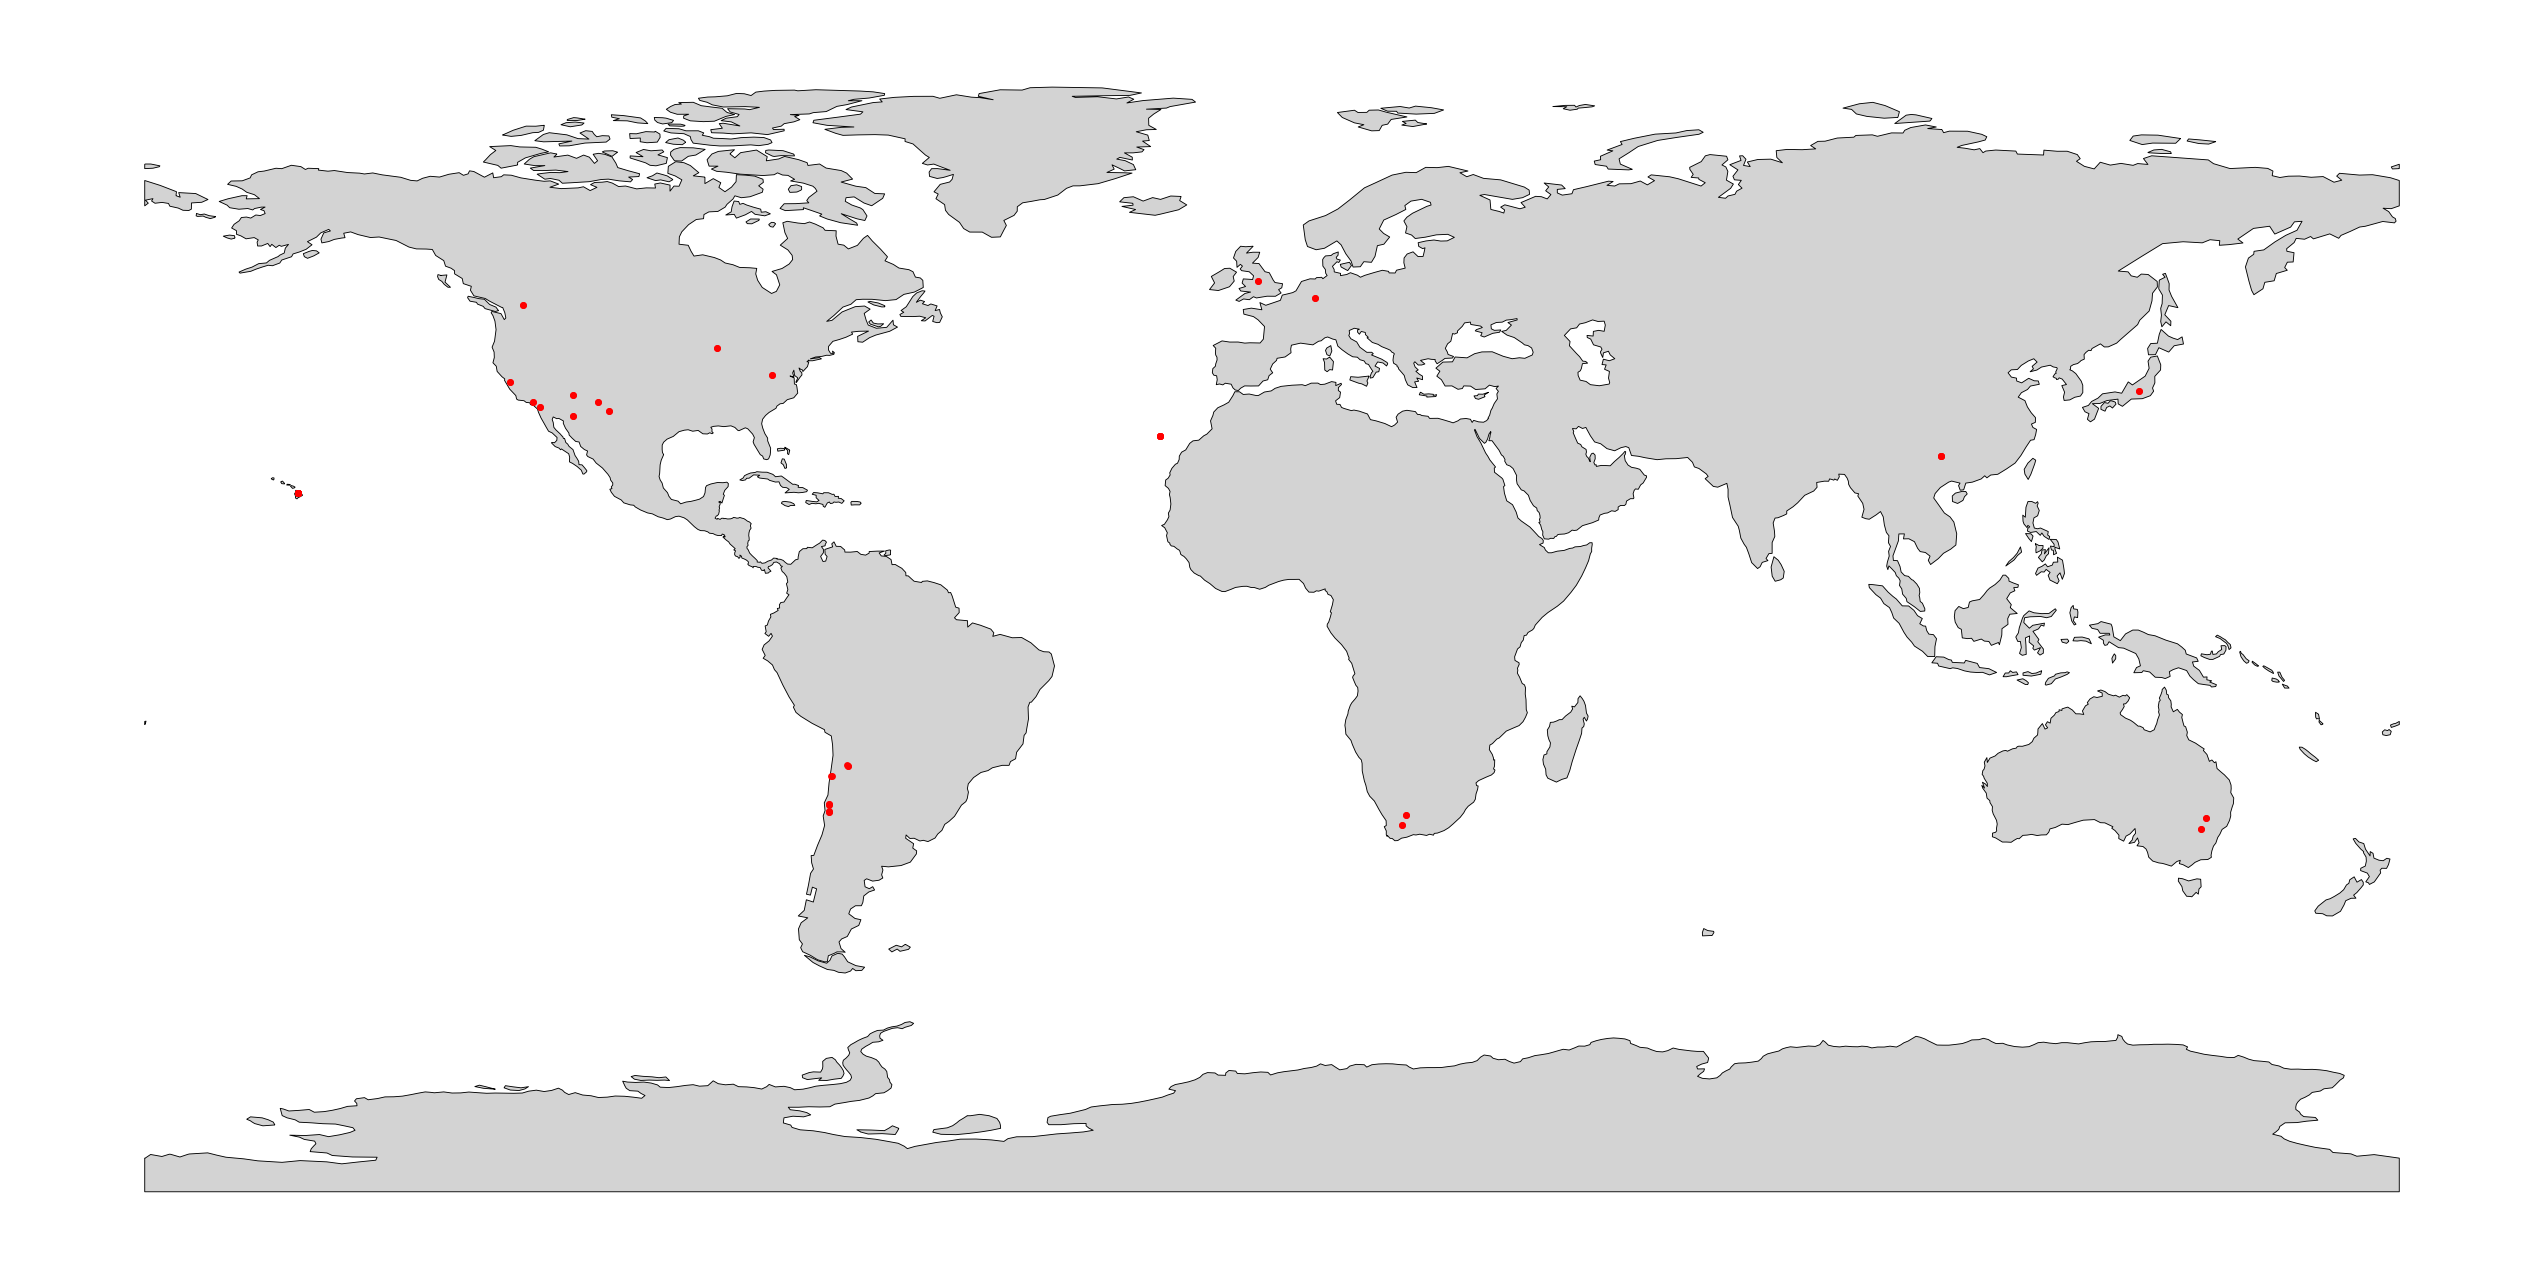

In [6]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=320)
m.plot(ax=ax, edgecolor='black', facecolor='lightgray', linewidth=0.2)
obs.plot(ax=ax, color='red', markersize=0.3, label='Observatorios')
ax.axis('off')

## Mapa de Chile

In [7]:
chile = gpd.read_file('Datos/Comunas/Comunas.shp').to_crs(epsg=4326).to_crs(epsg=32719)
chile = chile[chile['codregion'].isin([1, 2, 3, 4])]

#Quitamos isla de pascua y juan fernandez
chile = chile[~chile['Comuna'].isin(['Isla de Pascua', 'Juan Fernández'])]

In [8]:
#Unimos todas las comunas en una figura

def keep_only_mainland(geom):
    if geom.geom_type == 'Polygon':
        return geom
    elif geom.geom_type == 'MultiPolygon':
        return max(geom.geoms, key=lambda g: g.area)
    return geom

chile['geometry'] = chile['geometry'].buffer(0)

chile['geometry'] = chile['geometry'].apply(keep_only_mainland)
chile = gpd.GeoDataFrame(geometry=[chile.unary_union], crs=chile.crs)

In [9]:
# Eliminar huecos interiores

def remove_holes(geom):
    if geom.geom_type == 'Polygon':
        return Polygon(geom.exterior)
    elif geom.geom_type == 'MultiPolygon':
        return MultiPolygon([Polygon(g.exterior) for g in geom.geoms])
    return geom

chile['geometry'] = chile['geometry'].apply(remove_holes)

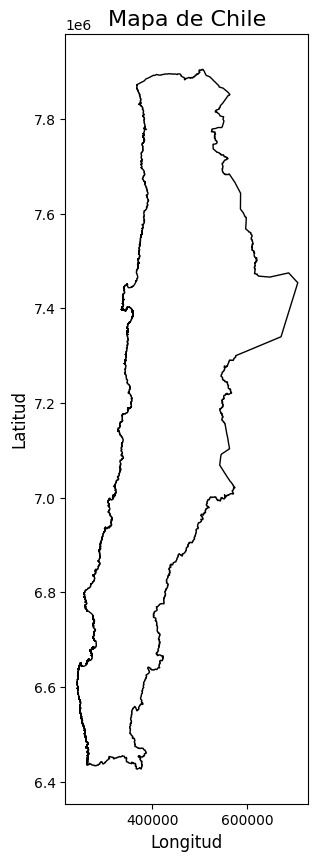

In [10]:
chile.plot(color='white', edgecolor='black', figsize=(10, 10))
# Añadir título y etiquetas
plt.title('Mapa de Chile', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.show()

### Creamos los hexagonos para Chile

In [11]:
# # 6. Crear hexágonos
# def create_hex_grid(gdf, hex_radius):
#     bounds = gdf.total_bounds
#     xmin, ymin, xmax, ymax = bounds
#     dx = 3/2 * hex_radius
#     dy = np.sqrt(3) * hex_radius
#     cols = int((xmax - xmin) / dx) + 2
#     rows = int((ymax - ymin) / dy) + 2

#     hexes = []
#     for row in range(rows):
#         for col in range(cols):
#             x = xmin + col * dx
#             y = ymin + row * dy
#             if col % 2 == 1:
#                 y += dy / 2
#             hex = Polygon([
#                 (x + hex_radius * np.cos(np.radians(angle)),
#                  y + hex_radius * np.sin(np.radians(angle)))
#                 for angle in range(0, 360, 60)
#             ])
#             hexes.append(hex)

#     return gpd.GeoDataFrame(geometry=hexes, crs=gdf.crs)

In [12]:
# hexagonos = create_hex_grid(chile, hex_radius=5000)
# hexagonos = gpd.overlay(hexagonos, chile, how='intersection').to_crs(epsg=4326)
# hexagonos.head(1)

In [13]:
# hexagonos.to_file("Datos/Hexagonos/ch/hexagonos_chile.shp", driver='ESRI Shapefile')
hexagonos = gpd.read_file("Datos/Hexagonos/ch/hexagonos_chile.shp").to_crs(epsg=4326)

### Obtenemos los hexagonos para los observatorios fuera de Chile

In [14]:
#obtenemos los id de los hexagonos donde estan los observatorios
obs_chile = obs[obs.geometry.within(hexagonos.unary_union)]
obs_chile = obs_chile.reset_index(drop=True)
obs_chile.head(1)

,Altitud (m,Ubicación,Año de In,Área Lent,geometry,Radio,Optico,Infrarrojo
0,5000,"Llano de Chajnantor, Antofagasta",2003,41001.06121734071,POINT (-67.7546 -23.0221),True,False,False


In [15]:
# a obs le quitamos los observatorios que estan en obs_chile
obs = obs[~obs.geometry.within(hexagonos.unary_union)]
obs.head(1)

,Altitud (m,Ubicación,Año de In,Área Lent,geometry,Radio,Optico,Infrarrojo
11,2124,Nuevo México-USA,1980,1256.6370614359173,POINT (-107.6184 34.0788),True,False,False


In [16]:
# #Le pedimos a chatgpr que nos creara un hexagono al rededor de los observatorios fuera de chile
# # y como no podemos reproyectar todo a 32719, transformamos cada locacion a su respectivo UTM
# def get_utm_epsg(lat, lon):
#     zone_number = int((lon + 180) / 6) + 1
#     if lat >= 0:
#         return 32600 + zone_number  # Norte
#     else:
#         return 32700 + zone_number  # Sur


In [17]:
# def create_hexagon(center, radius_m=5000):
#     angles = np.linspace(0, 360, 6, endpoint=False)
#     coords = [
#         (
#             center.x + radius_m * np.cos(np.radians(a)),
#             center.y + radius_m * np.sin(np.radians(a))
#         )
#         for a in angles
#     ]
#     return Polygon(coords)

In [18]:
# hexes = []
# attributes = []

# for _, row in obs.iterrows():
#     lon, lat = row.geometry.x, row.geometry.y
#     epsg = get_utm_epsg(lat, lon)
    
#     # Crear GeoDataFrame con un solo punto y proyectarlo
#     gdf_point = gpd.GeoDataFrame(geometry=[Point(lon, lat)], crs='EPSG:4326').to_crs(epsg=epsg)
#     projected_point = gdf_point.geometry.iloc[0]

#     # Crear hexágono en proyección métrica
#     angles = np.linspace(0, 360, 6, endpoint=False)
#     coords = [
#         (
#             projected_point.x + 5000 * np.cos(np.radians(a)),
#             projected_point.y + 5000 * np.sin(np.radians(a))
#         )
#         for a in angles
#     ]
#     hex_local = Polygon(coords)

#     # Reproyectar hexágono a EPSG:4326
#     hex_global = gpd.GeoSeries([hex_local], crs=f"EPSG:{epsg}").to_crs(epsg=4326).iloc[0]

#     hexes.append(hex_global)
#     attributes.append(row.drop("geometry"))

# # Crear GeoDataFrame final con hexágonos y atributos originales
# hex_ext = gpd.GeoDataFrame(attributes, geometry=hexes, crs="EPSG:4326")
# hex_ext.to_file("Datos/Hexagonos/ext/hexagonos_ext.shp", driver='ESRI Shapefile')
# hex_ext = gpd.read_file("Datos/Hexagonos/ext/hexagonos_ext.shp").to_crs(epsg=4326)

In [19]:
# #Juntamos los hexagonos de los observatorios con los hexagonos de la grilla
# hexagonos = pd.concat([hexagonos, hex_ext], ignore_index=True)
# #creamos un id para los hexagonos
# hexagonos['id'] = range(1, len(hexagonos) + 1)
# #pasamos a geopandas
# hexagonos = gpd.GeoDataFrame(hexagonos, geometry='geometry', crs="EPSG:4326").to_crs(epsg=4326)
# hexagonos = hexagonos[["geometry", "id"]]
# hexagonos.head(1)

### Guardamos los hexagonos

In [20]:
# path = "Datos/Hexagonos"
# os.makedirs(path, exist_ok=True)
# hexagonos.to_file(f"{path}/hexagonos.shp", driver='ESRI Shapefile')

### Lo volvemos a cargar

In [21]:
hexagonos = gpd.read_file("Datos/Hexagonos/hexagonos.shp").to_crs(epsg=4326)
chile = chile.to_crs(epsg=4326)

In [22]:
obs = pd.concat([obs, obs_chile], ignore_index=True) ; obs_chile = None
obs = obs.reset_index(drop=True)
obs = gpd.GeoDataFrame(obs, geometry='geometry', crs="EPSG:4326")
print(obs.shape)
obs.head(1)

(71, 8)


,Altitud (m,Ubicación,Año de In,Área Lent,geometry,Radio,Optico,Infrarrojo
0,2124,Nuevo México-USA,1980,1256.6370614359173,POINT (-107.6184 34.0788),True,False,False


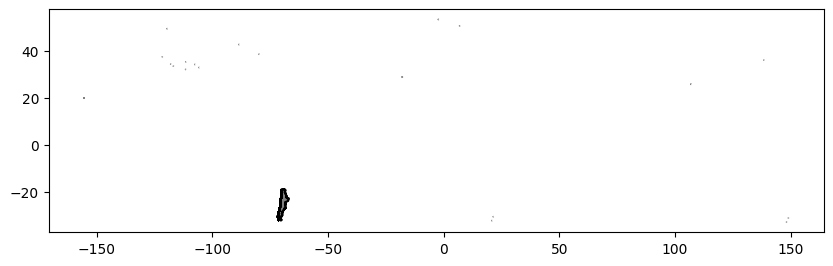

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))
chile.boundary.plot(ax=ax, color='black')
hexagonos.plot(ax=ax, edgecolor='gray', facecolor='none')
plt.show()

In [24]:
# # a cada observatorio le asignamos el hexagono al que pertenece
obs['hex_id'] = obs.geometry.apply(lambda x: hexagonos[hexagonos.contains(x)].id.values[0] if not hexagonos[hexagonos.contains(x)].empty else None)
obs.head(1)

,Altitud (m,Ubicación,Año de In,Área Lent,geometry,Radio,Optico,Infrarrojo,hex_id
0,2124,Nuevo México-USA,1980,1256.6370614359173,POINT (-107.6184 34.0788),True,False,False,4690


### Subimos el archivo como asset a Google Earth Engine (manualmente), y lo leemos

In [25]:
asset_path = "projects/ee-tomasromero/assets/hexagonos"
hex_fc = ee.FeatureCollection(asset_path)

# Obtenemos la informacion de los Satelites

In [26]:
tasks = []

In [27]:
def export_satellite_band_to_hexagons(asset_path, image, band_name, output, scale=500, collection=True):
    if collection:
        image = image.select(band_name).mean()
    
    hex_fc = ee.FeatureCollection(asset_path)

    reduced = image.reduceRegions(
        collection=hex_fc,
        reducer=ee.Reducer.mean(),
        scale=scale
    )

    task = ee.batch.Export.table.toDrive(
        collection=reduced,
        description=f'{output}',
        fileNamePrefix=f'{output}',
        fileFormat='CSV'
    )
    return task


### Contaminacion Luminica
[VIIRS Stray Light Corrected Nighttime](https://developers.google.com/earth-engine/datasets/catalog/NOAA_VIIRS_DNB_MONTHLY_V1_VCMSLCFG?hl=es-419)

In [28]:
image = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG") \
    .filterDate(startDate, endDate)

tasks.append(export_satellite_band_to_hexagons(asset_path, image, "avg_rad", "contaminacion_luminica"))

## Nubosidad
[Terra Atmosphere Monthly Global Product](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD08_M3?hl=es-419)

In [29]:
image = ee.ImageCollection("MODIS/061/MOD08_M3") \
    .filterDate(startDate, endDate)

tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Cirrus_Fraction_SWIR_FMean', "nubosidad1"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Cloud_Optical_Thickness_Liquid_Log_Mean_Mean', "nubosidad2"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Cloud_Optical_Thickness_Liquid_Mean_Uncertainty', "nubosidad3"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Cirrus_Fraction_SWIR_FStd', "nubosidad4"))


### Elevacion
[NASA SRTM Digital Elevation 30m](https://developers.google.com/earth-engine/datasets/catalog/USGS_SRTMGL1_003?hl=es-419)

In [30]:
image = ee.Image('USGS/SRTMGL1_003')

tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'elevation', "elevacion", collection=False))

### Precipitacion
[TCHIRPS Daily: Climate Hazards Center InfraRed Precipitation](https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY?hl=es-419)

In [31]:
image = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
                  .filter(ee.Filter.date(startDate, endDate))

tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'precipitation', "precipitacion"))

### Calidad del aire
[Terra & Aqua MAIAC Land Aerosol Profundidad óptica Diario 1 km](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD19A2_GRANULES?hl=es-419)

In [32]:
image = ee.ImageCollection('MODIS/061/MCD19A2_GRANULES') \
          .filterDate(startDate, endDate)

tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Optical_Depth_047', "calidad_aire1"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Optical_Depth_055', "calidad_aire2"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Column_WV', "calidad_aire3"))

### Gases Atmosfericos
[Sentinel-5P OFFL AER AI: Índice de Aerosol UV fuera de línea ](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_AER_AI?hl=es-419)

In [33]:
image = ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_AER_AI') \
          .filterDate(startDate, endDate)
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'absorbing_aerosol_index', "gases_atmosfericos"))

## Uso del Suelo
[ESA WorldCover 10m v100](https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100?hl=es-419)


In [34]:
image = ee.Image('ESA/WorldCover/v100/2020')
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Map', "uso_suelo", collection=False))

### Pasamos toda la informacion de los satelites a csv, los cuales cargaran en drive

In [35]:
# for t in tasks:
#     t.start()

### Cargamos cada csv y lo mergeamos con los hexagonos

In [36]:
files = glob("Datos/satelites/*.csv")
for file in files:
    columna = file.split("\\")[1].split(".")[0]
    hexagonos[columna] = pd.read_csv(file, index_col=0)['mean'].values
hexagonos.head(1)

,id,geometry,calidad_aire1,calidad_aire2,calidad_aire3,contaminacion_luminica,elevacion,gases_atmosfericos,nubosidad1,nubosidad2,nubosidad3,nubosidad4,precipitacion,uso_suelo
0,1,"POLYGON ((-71.39246 -32.18932, -71.33947 -32.1...",144.344311,103.786436,274.265615,0.29762,3290.08002,0.222616,9385.0,2955.444444,291.222222,823.416667,0.06109,54.294491


In [37]:
obs

,Altitud (m,Ubicación,Año de In,Área Lent,geometry,Radio,Optico,Infrarrojo,hex_id
0,2124,Nuevo México-USA,1980,1256.6370614359173,POINT (-107.6184 34.0788),True,False,False,4690
1,824,Virginia Occidental-USA,2000,7853.981633974483,POINT (-79.8399 38.4331),True,False,False,4691
2,4092,Mauna Kea-Hawái-USA,1987,78.53981633974483,POINT (-155.4762 19.8226),True,False,False,4692
3,4080,Mauna Kea-Hawái-USA,2002,56.54866776461628,POINT (-155.4758 19.8243),True,False,False,4692
4,4145,Mauna Kea-Hawái-USA,1993,76.96902001294993,POINT (-155.4783 19.8264),False,True,True,4692
...,...,...,...,...,...,...,...,...,...
66,2200,"Cerro Tololo, Coquimbo",1963,12.566370614359172,POINT (-70.8061 -30.1692),False,True,False,472
67,2737,"Cerro Pachón, Coquimbo",1994,51.51838900400386,POINT (-70.7366 -30.2407),False,True,True,451
68,2663,"Cerro Pachón, Coquimbo",2014,55.41985163906199,POINT (-70.7492 -30.2444),False,True,False,451
69,2400,"Cerro Las Campanas, Atacama",1999,66.46813142637272,POINT (-70.6925 -29.0144),False,True,False,760


### Normalizamos los datos

In [38]:
#Seleccionamos columnas numéricas relevantes
variables = [
    'calidad_aire1', 'calidad_aire2', 'calidad_aire3',
    'contaminacion_luminica', 'elevacion', 'gases_atmosfericos',
    'nubosidad1', 'nubosidad2', 'nubosidad3', 'nubosidad4',
    'precipitacion', 'uso_suelo'
]

scaler = MinMaxScaler()
hexagonos[variables] = scaler.fit_transform(hexagonos[variables])
hexagonos.head(1)

,id,geometry,calidad_aire1,calidad_aire2,calidad_aire3,contaminacion_luminica,elevacion,gases_atmosfericos,nubosidad1,nubosidad2,nubosidad3,nubosidad4,precipitacion,uso_suelo
0,1,"POLYGON ((-71.39246 -32.18932, -71.33947 -32.1...",0.428796,0.405663,0.096729,0.001855,0.527677,0.559921,0.921562,0.635892,0.351104,0.186624,0.013152,0.632107


### Categorizamos

### Formamos un dataframe de informacion de los hexagonos con el observatorio

In [39]:
obs_hex = pd.merge(obs, hexagonos, left_on='hex_id', right_on='id', how='left')
obs_hex.drop(columns=['hex_id', 'geometry_y'], inplace=True)
obs_hex.rename(columns={'geometry_x': 'geometry'}, inplace=True) #nos quedamos con la geometría de punto
obs_hex.drop(columns=['Área Lent', 'Ubicación', 'Año de In', 'Altitud (m'], inplace=True)
obs_hex['Radio'] = obs_hex['Radio'].astype(int)
obs_hex['Optico'] = obs_hex['Optico'].astype(int)
obs_hex['Infrarrojo'] = obs_hex['Infrarrojo'].astype(int)

obs_hex.head(1)

,geometry,Radio,Optico,Infrarrojo,id,calidad_aire1,calidad_aire2,calidad_aire3,contaminacion_luminica,elevacion,gases_atmosfericos,nubosidad1,nubosidad2,nubosidad3,nubosidad4,precipitacion,uso_suelo
0,POINT (-107.6184 34.0788),1,0,0,4690,0.000041,0.000005,0.074615,0.000183,0.765562,0.539272,0.986453,0.576199,0.155967,0.045371,0.068844,0.713764


In [40]:
# obs_hex = gpd.sjoin(obs, hexagonos, how="inner", predicate="within")

Posteriormente, creamos un dataframe con los hexagonos que no tienen observatorios

In [41]:
# Extraer los IDs de los hexágonos donde hay observatorios
ids_obs_hex = obs_hex["id"].unique()

# Filtrar los hexágonos que NO están en la lista
hexagonos = hexagonos[~hexagonos["id"].isin(ids_obs_hex)].copy()

In [42]:
#los 4 axtremos de chile
extremos = {
    'Norte': chile.unary_union.bounds[3],
    'Sur': chile.unary_union.bounds[1],
    'Oeste': chile.unary_union.bounds[0],
    'Este': chile.unary_union.bounds[2]
}


# Filtrar usando las coordenadas de los centroides
hexagonos = hexagonos[
    (hexagonos.geometry.centroid.x >= extremos['Oeste']) &
    (hexagonos.geometry.centroid.x <= extremos['Este']) &
    (hexagonos.geometry.centroid.y >= extremos['Sur']) &
    (hexagonos.geometry.centroid.y <= extremos['Norte'])
]
hexagonos.head(1)

,id,geometry,calidad_aire1,calidad_aire2,calidad_aire3,contaminacion_luminica,elevacion,gases_atmosfericos,nubosidad1,nubosidad2,nubosidad3,nubosidad4,precipitacion,uso_suelo
0,1,"POLYGON ((-71.39246 -32.18932, -71.33947 -32.1...",0.428796,0.405663,0.096729,0.001855,0.527677,0.559921,0.921562,0.635892,0.351104,0.186624,0.013152,0.632107


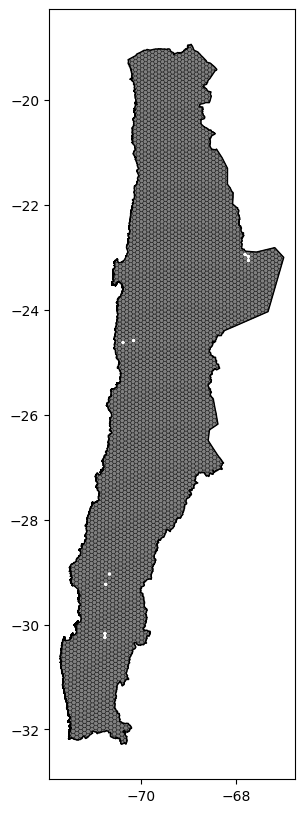

In [43]:
#Ploteamos el hexagonos
fig, ax = plt.subplots(figsize=(10, 10))
chile.boundary.plot(ax=ax, color='black', linewidth=1)
hexagonos.plot(ax=ax, color='gray', edgecolor='black', linewidth=0.3, label='Hexágonos sin observatorios')
plt.show()

## ANTENAS CELULARES

In [44]:
antenas = gpd.read_file("Datos/antenas/antenas.shp").to_crs(epsg=4326)
antenas.head(1)

,frecuencia,banda_frec,ancho_band,tecnologia,tipo_acces,geometry
0,1900.0,UHF,30000,GSM(2G),TDMA,POINT (-70.30583 -18.48417)


In [45]:
# Aplicamos get_dummies a estas columnas, excluyendo automáticamente la columna geometry
antenas = pd.get_dummies(antenas, columns=['banda_frec', 'tecnologia', 'tipo_acces'])
antenas

,frecuencia,ancho_band,geometry,banda_frec_AWS-E,banda_frec_SHF,banda_frec_UHF,banda_frec_VHF,tecnologia_3G/LTE,tecnologia_5G,tecnologia_5G(5G),tecnologia_5G(5G)/LTE(4G),tecnologia_5G/LTE,tecnologia_GSM,tecnologia_GSM(2G),tecnologia_GSM(2G)/UMTS(3G),tecnologia_LTE,tecnologia_LTE - WCDMA,tecnologia_LTE / UMTS,tecnologia_LTE ADVANCES PRO,tecnologia_LTE Advanced Pro,tecnologia_LTE Advanced Pro(5G),tecnologia_LTE UMTS,tecnologia_LTE WCDMA,tecnologia_LTE(4G),tecnologia_LTE(4G)/GSM(2G),tecnologia_LTE-WCDMA,tecnologia_LTE/WCDMA,tecnologia_UMTS,tecnologia_UMTS(3G),tecnologia_UMTS(3G)/LTE Advanced Pro(5G),tecnologia_UMTS(3G)/LTE(4G),tecnologia_WCDMA,tipo_acces_256 QAM,tipo_acces_CDMA,tipo_acces_FDD,tipo_acces_FDD/SC-FDMA,tipo_acces_FDD/TDMA,tipo_acces_FDMA-FDD,tipo_acces_FDMA-FDD - WCDMA,tipo_acces_MIMO Masivo,tipo_acces_ODFMDA,tipo_acces_OFDM / SC-FDMA,tipo_acces_OFDM(DL) SC-FDMA(UL),tipo_acces_OFDM(DL)/SC-FDMA(UL),tipo_acces_OFDM(DL); SC-FDMA(UL),tipo_acces_OFDM/SC-FDMA,tipo_acces_OFDMA,tipo_acces_OFDMA SC-FDMA,tipo_acces_OFDMA/SC-FDMA,tipo_acces_SC-FDMA,tipo_acces_SC-FDMA (UL) ; OFDMA (DL) WCDMA,tipo_acces_SC-FDMA / OFDMA,tipo_acces_SC-FDMA(UL)/OFDM(DL),tipo_acces_TDMA,"tipo_acces_TDMA, FDMA",tipo_acces_TDMA/FDD/WCDMA,tipo_acces_TDMA/WCDMA,tipo_acces_WCDMA,tipo_acces_WCDMA / OFDMA,tipo_acces_WCDMA/FDD,tipo_acces_WCDMA/OFDMA,tipo_acces_ofdma,tipo_acces_wcdma
0,1900.0,30000,POINT (-70.30583 -18.48417),False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,1900.0,30000,POINT (-70.28917 -18.45417),False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
2,1900.0,30000,POINT (-70.29417 -18.47083),False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
3,1900.0,30000,POINT (-70.29417 -18.47083),False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,850.0,25000,POINT (-69.96222 -19.81306),False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6200,3500.0,50000,POINT (-71.15842 -31.11994),False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

# MODELO

### Test con respecto a una prediccion en base a la informacion de un vector ideal

Con respecto ahora, tomaremos la siguiente tabla con respecto a la información que poseemos.

| Requisito                  | Telescopio Óptico                 | Telescopio Radio                         |
| -------------------------- | --------------------------------- | ---------------------------------------- |
| **Nubosidad**              | Crítica (se necesita cielo claro) | No tan importante (puede observar nubes) |
| **Contaminación lumínica** | Crítica                           | Irrelevante                              |
| **Altitud**                | Deseable (menos atmósfera)        | No esencial                              |
| **Gases atmosféricos**     | Afecta la refracción (importa)    | Puede afectar bandas específicas         |
| **Ruido electromagnético** | No relevante                      | Muy relevante (no lo tienes aún)         |
| **Precipitación**          | Afecta ambas pero es tolerable    | Afecta instalaciones, pero menos         |


In [46]:
obs_opticos = obs_hex[obs_hex['Optico'] == 1]
obs_radio = obs_hex[obs_hex['Radio'] == 1]
obs_infrarrojo = obs_hex[obs_hex['Infrarrojo'] == 1]

In [47]:
#Vectores ideales para ópticos y radio (en base a los observatorios ya obtenidos)
vector_ideal_optico = obs_opticos[variables].mean()
vector_ideal_radio = obs_radio[variables].mean()
vector_ideal_infrarrojo = obs_infrarrojo[variables].mean()

In [48]:
hex_norm = hexagonos.copy()
hex_norm[variables] = scaler.transform(hex_norm[variables])

# Distancia a condiciones ópticas
hex_norm['dist_optico'] = cdist(hex_norm[variables], [vector_ideal_optico], metric='euclidean')[:, 0]

# Distancia a condiciones de radio
hex_norm['dist_radio'] = cdist(hex_norm[variables], [vector_ideal_radio], metric='euclidean')[:, 0]

# Distancia a condiciones de infrarrojo
hex_norm['dist_infrarrojo'] = cdist(hex_norm[variables], [vector_ideal_infrarrojo], metric='euclidean')[:, 0]

In [49]:
top_optico = hex_norm.nsmallest(10, 'dist_optico')
top_radio = hex_norm.nsmallest(10, 'dist_radio')
top_infrarrojo = hex_norm.nsmallest(10, 'dist_infrarrojo')

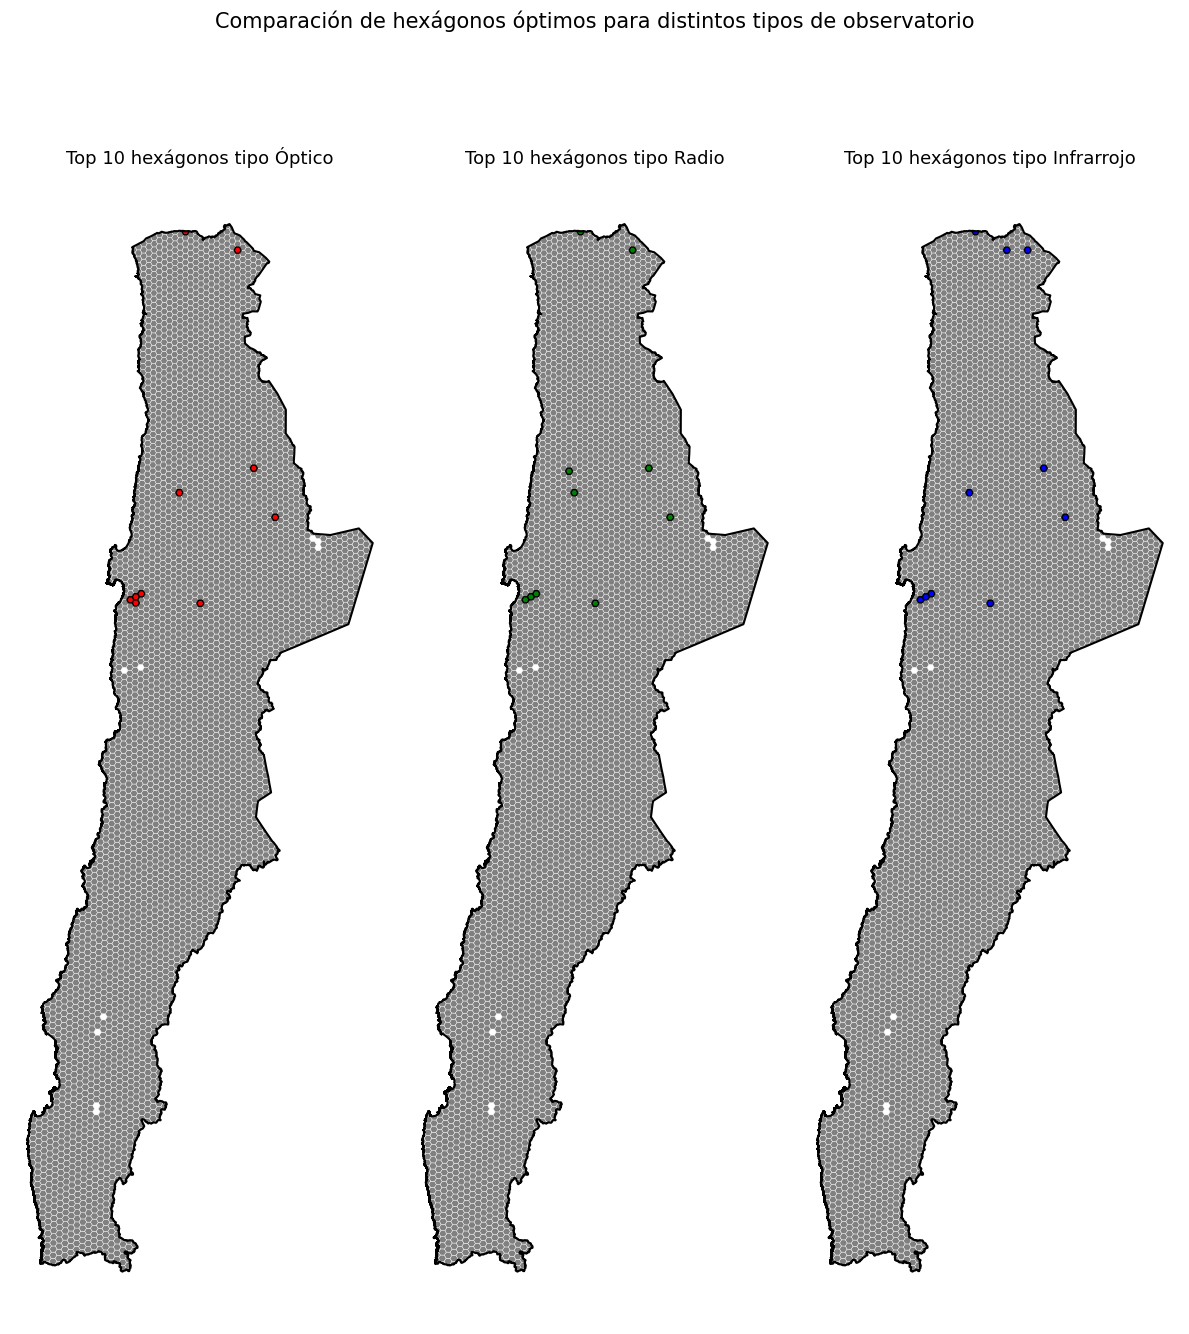

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(12, 15), sharex=True, sharey=True)

# Mapa óptico
chile.boundary.plot(ax=axes[0], color='black')
hexagonos.plot(ax=axes[0], color='gray', edgecolor='white', linewidth=0.3)
top_optico.plot(ax=axes[0], color='red', edgecolor='black', linewidth=1)
#obs.plot(ax=axes[0], color='blue', markersize=10)
axes[0].set_title('Top 10 hexágonos tipo Óptico', fontsize=13)
axes[0].set_axis_off()

# Mapa radio
chile.boundary.plot(ax=axes[1], color='black')
hexagonos.plot(ax=axes[1], color='gray', edgecolor='white', linewidth=0.3)
top_radio.plot(ax=axes[1], color='green', edgecolor='black', linewidth=1)
#obs.plot(ax=axes[1], color='blue', markersize=10)
axes[1].set_title('Top 10 hexágonos tipo Radio', fontsize=13)
axes[1].set_axis_off()

# Mapa infrarrojo
chile.boundary.plot(ax=axes[2], color='black')
hexagonos.plot(ax=axes[2], color='gray', edgecolor='white', linewidth=0.3)
top_infrarrojo.plot(ax=axes[2], color='blue', edgecolor='black', linewidth=1)
#obs.plot(ax=axes[2], color='blue', markersize=10)
axes[2].set_title('Top 10 hexágonos tipo Infrarrojo', fontsize=13)
axes[2].set_axis_off()

plt.suptitle("Comparación de hexágonos óptimos para distintos tipos de observatorio", fontsize=15)
plt.tight_layout()
plt.show()

- Ideal encontrar informacion de ruido electromagnetico, para el telescopio radio

### Indice de Moran

In [ ]:
gdf = hexagonos.copy()

w = Queen.from_dataframe(gdf)
w.transform = 'r'

resultados = []

#Las variables ya estan definidas en la parte de normalizacion
for var in variables:
    # Asegura que no haya NaNs en la variable actual
    y = gdf[var].dropna().values
    gdf_valid = gdf.loc[gdf[var].notna()]
    w_valid = Queen.from_dataframe(gdf_valid)
    w_valid.transform = 'r'

    moran = Moran(y, w_valid)
    resultados.append({
        'variable': var,
        "Moran's I": round(moran.I, 4),
        "p-value": round(moran.p_sim, 4),
        "significativo": moran.p_sim < 0.05
    })

df_resultados = pd.DataFrame(resultados).sort_values("p-value")
print(df_resultados)


Ojo que hay muchas islas :o

| Variable            | Moran's I | p-valor | Interpretación                                     |
| ------------------- | --------- | ------- | -------------------------------------------------- |
| gases\_atmosfericos | 0.0478    | 0.001   | **Agrupamiento claro** de zonas similares en gases |
| precipitacion       | 0.0953    | 0.001   | Fuerte agrupamiento en cuanto a precipitación      |
| uso\_suelo          | 0.0394    | 0.002   | Zonas similares en uso del suelo están cerca       |
| nubosidad1          | 0.0254    | 0.006   | Hay zonas cercanas con nubosidad similar           |
| nubosidad4          | 0.0178    | 0.028   | También agrupadas, aunque menos intenso            |


El **Índice de Moran global** mide si una variable está espacialmente agrupada o no. Aplicarlo a nuestras variables relevantes sirve para:
- Con esto justificamos el uso de métodos espaciales

- Si una variable no presenta autocorrelación espacial, no tiene sentido usar técnicas como clustering espacial o segmentación por cercanía.

- Sí tiene autocorrelación (como precipitación, uso_suelo, gases_atmosféricos en este caso), entonces los valores similares están geográficamente cerca, y eso habilita el uso de técnicas como KMeans, HDBSCAN, LISA, etc.

Esto permite que nos enfoquemos en las variables que sí aportan valor espacialmente, y descartemos o tomemos en cuenta las que son puramente aleatorias en el espacio (como calidad_aire3 en tus resultados).

### Moran Local (LISA)

El Moran Local **(LISA)** detecta dónde están los grupos estadísticamente significativos. En este caso:
- Identifica zonas “favorables” o “desfavorables”

- Por ejemplo, zonas con bajo nivel de gases atmosféricos rodeadas de otras zonas similares (Low-Low) -> ideales para astronomía óptica.

- O zonas de alta contaminación atmosférica rodeadas de otras similares (High-High) -> zonas que deberías descartar completamente.

*No es lo mismo que haya un buen hexágono aislado a que haya una zona entera de condiciones favorables.*

### Clustering espacial.

Por ultimo y no menos importante, el clustering espacial. Idealmente encontrar clusters de hexágonos que cumplan con los requisitos de los telescopios ópticos y radio, para identificar zonas optimas con condiciones similares.

Cosas por hacer (No es necesario que hagas todo pelao, avisame hasta donde quieres llegar y de ahi puedo tambien seguir yo :>):
- [ ] Intentar ver lo del ruido electromagnetico, para poder agregarlo como variable importante para el telescopio de radio
- [ ] En base a Moran, ver si hay autocorrelacion espacial en las variables
- [ ] Utilizar LISA para ver donde estan los grupos estadisticamente significativos
- [ ] Utilizar clusteirng para ver si hay agrupaciones de hexagonos con condiciones optimas similares, aqui podriamos utilizar los observatorios como referencia
- [ ] Intentar empezar a generar conclusiones sobre posibles zonas en base a los hexagonos.

Deje una pequeña mini descripcion en algunos para ir viendo su importancia jejeje